## ライブラリをインポート

In [1]:
# 必要なライブラリをimport
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 乱数を発生させる

今回は、母平均と母分散がわかっている状態にはなりますが、ある平均・分散の正規分布に従ったランダムな数値データを取得することで、標本のデータをサンプリングすることにします。

最初に、乱数種を設定します。

seedというのが、乱数種を指定する関数です。乱数種を指定しない場合、毎回異なる乱数が生成されます。乱数は欲しいけれども再現性（何度試しても同じ結果になること）がないのは困ります。このseedを設定しておくことで、常に同じ出力結果が生成されます。ここでは乱数種を1としましたが、数字であれば何でも自由に決めることができます。

In [17]:
# 乱数種を設定
np.random.seed(1)

次に、平均15、分散1（単位：cm）の正規分布に従う乱数を10000個発生させてみましょう。

In [21]:
# 平均15・分散1の正規分布に従う乱数を10000個発生させる
norm_dist = stats.norm(loc=15, scale=1)
data1 = norm_dist.rvs(size=10000)

こちらでは、stats.normメソッドによって、平均15、分散1の正規分布の母集団を作っています。そして、rvsメソッドによって、上記の母集団から10000個の数値をサンプリングしています。

rvsメソッドで取得した結果を確認します。

In [22]:
data1

array([14.87752609, 15.22816982, 14.64769487, ..., 17.4084338 ,
       15.88278555, 14.90040369])

## matplotlibでヒストグラムを作成

(array([  34.,  225.,  949., 2195., 2937., 2326., 1036.,  256.,   38.,
           4.]),
 array([11.54859709, 12.31054915, 13.07250121, 13.83445327, 14.59640533,
        15.35835739, 16.12030944, 16.8822615 , 17.64421356, 18.40616562,
        19.16811768]),
 <BarContainer object of 10 artists>)

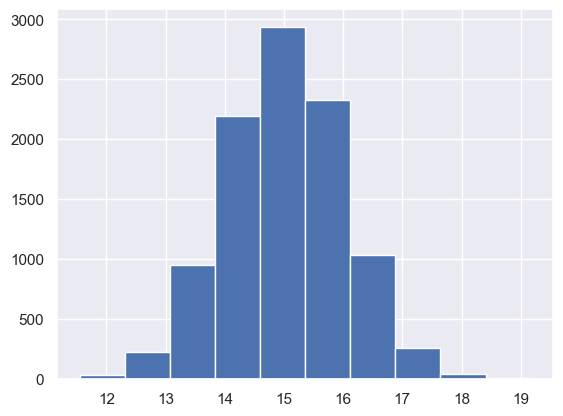

In [23]:
# matplotlibでヒストグラムを作成
plt.hist(data1)

柱の数を変更したい場合には plt.hist(data1, bins=20) と指定します。

(array([  12.,   22.,   73.,  152.,  351.,  598.,  950., 1245., 1458.,
        1479., 1308., 1018.,  671.,  365.,  186.,   70.,   31.,    7.,
           2.,    2.]),
 array([11.54859709, 11.92957312, 12.31054915, 12.69152518, 13.07250121,
        13.45347724, 13.83445327, 14.2154293 , 14.59640533, 14.97738136,
        15.35835739, 15.73933342, 16.12030944, 16.50128547, 16.8822615 ,
        17.26323753, 17.64421356, 18.02518959, 18.40616562, 18.78714165,
        19.16811768]),
 <BarContainer object of 20 artists>)

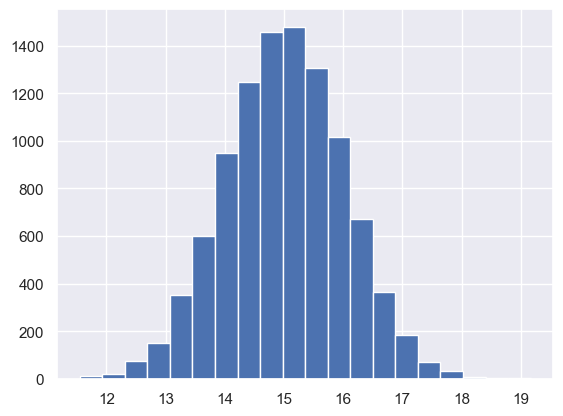

In [24]:
plt.hist(data1, bins=20)

## seabornでヒストグラムと分布を作成

ヒストグラムに分布を上書きしてみましょう。描画にはseabornのhistplotメソッドを使用します。kde=True とすることで、分布も表示されます。

<Axes: ylabel='Count'>

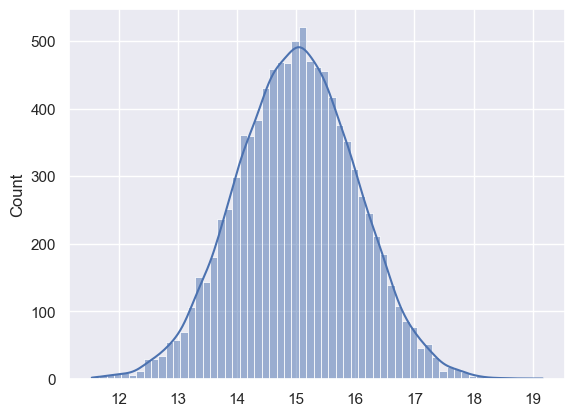

In [26]:
# seabornでヒストグラムと分布を作成
sns.histplot(data1, kde=True)

## 母平均の点推定

In [27]:
# 母平均の点推定（標本平均を母平均の推定値として扱う）
mu = np.mean(data1)
mu

15.009435413447104

##  母分散の点推定（不偏分散）

不偏分散を求める際は、ddofの引数を1にします。ddof=1とすることにより、不偏分散の n−1で割る 計算が行われます。

In [32]:
# 母分散の点推定（不偏分散を母分散の推定値として扱う）
sigma2 = np.var(data1, ddof=1)
sigma2

1.0024802087387725

## 標準誤差（SE）を計算

Standard Error = 不偏標準偏差 / √標本数（ルート標本数）を計算して標準誤差を求めます。

In [33]:
# 標準誤差（SE）
sigma = np.std(data1, ddof=1)  #普遍標準偏差
se = sigma/np.sqrt(len(data1))  #.sqrt(xx)はxxのルート
se

0.0100123933639204

## 95%信頼区間を計算

信頼区間は、stats.t.intervalメソッドを使用し、上記で計算した値を引数とすることで計算できます。なお、戻り値は、計算された信頼区間の下限値および上限値の値となります。

**なお、Python実習では、標準化しなくても下側信頼限界と上側信頼限界の値を求められるメソッドを使っています(t値をpythonが計算してくれるので)。Pythonを使う場合は標準化を無理に行う必要はありません。

In [34]:
# 自由度（標本数 - 1）を計算
df = len(data1) - 1  #n-1

# 95%信頼区間の下限値と上限値を計算
interval = stats.t.interval(0.95, df, loc=mu, scale=se)
interval

(14.989809107323273, 15.029061719570935)